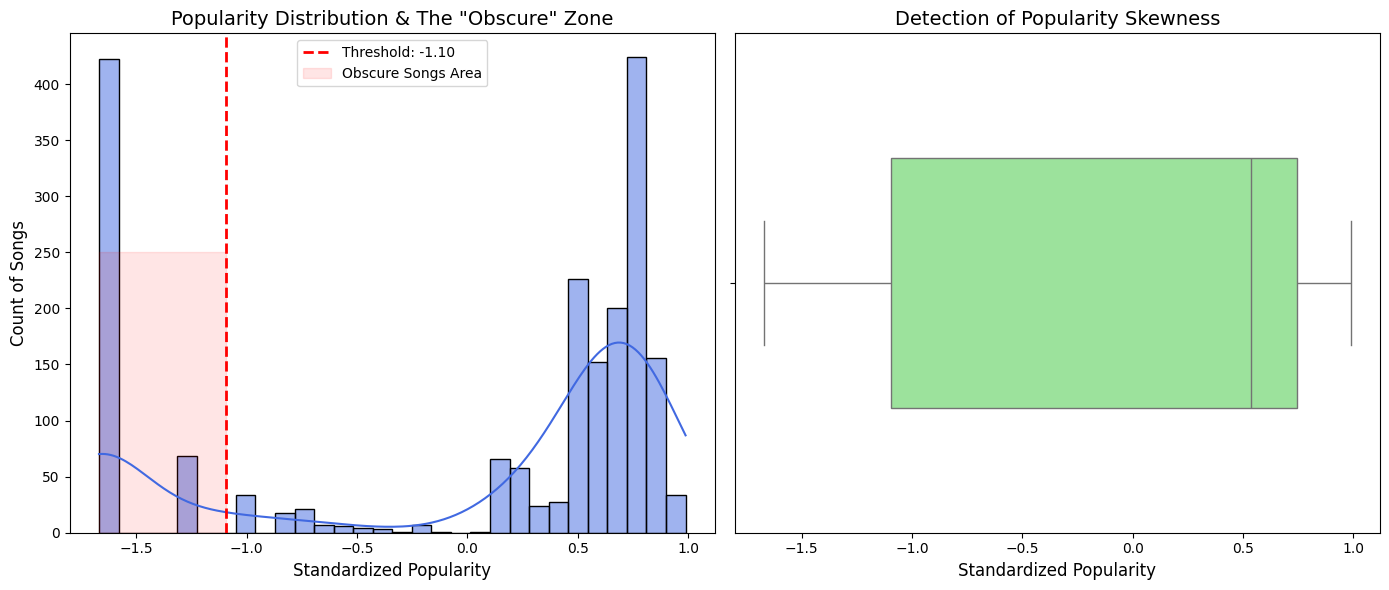

--- DATASET CLEANING SUMMARY ---
Original Song Count: 1960
Filtered Song Count: 1470
Total Songs Removed: 490 (Bottom 25%)
New Mean Popularity: 0.5382 (Was 0.00)
---------------------------------
Success: 'df_filtered.csv' created and ready for regression.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the original transformed dataset
df = pd.read_csv('df_transformed.csv')

# 2. Visualize the Problem: The "Long Tail" of Low Popularity
plt.figure(figsize=(14, 6))

# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(df['popularity'], kde=True, color='royalblue', bins=30)
# Calculate the 25th percentile threshold
threshold = df['popularity'].quantile(0.25)
plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.2f}')
plt.fill_betweenx([0, 250], df['popularity'].min(), threshold, color='red', alpha=0.1, label='Obscure Songs Area')
plt.title('Popularity Distribution & The "Obscure" Zone', fontsize=14)
plt.xlabel('Standardized Popularity', fontsize=12)
plt.ylabel('Count of Songs', fontsize=12)
plt.legend()

# Boxplot to show spread and density
plt.subplot(1, 2, 2)
sns.boxplot(x=df['popularity'], color='lightgreen', width=0.5)
plt.title('Detection of Popularity Skewness', fontsize=14)
plt.xlabel('Standardized Popularity', fontsize=12)

plt.tight_layout()
plt.show()

# 3. Create a filtered DataFrame (Removing the bottom 25%)
df_filtered = df[df['popularity'] > threshold].copy()

# 4. Impact Summary for the team
print("--- DATASET CLEANING SUMMARY ---")
print(f"Original Song Count: {len(df)}")
print(f"Filtered Song Count: {len(df_filtered)}")
print(f"Total Songs Removed: {len(df) - len(df_filtered)} (Bottom 25%)")
print(f"New Mean Popularity: {df_filtered['popularity'].mean():.4f} (Was 0.00)")
print("---------------------------------")

# 5. Save the new dataset for the next modeling steps
df_filtered.to_csv('df_filtered.csv', index=False)
print("Success: 'df_filtered.csv' created and ready for regression.")

as you can see, there is a lot of songs with popularity 0. this will make regression really weird. i removed these songs with 0 popularity to make regression more meaningfull
